<a href="https://colab.research.google.com/github/Boss-diamond/global_cattle_milk_yield_prediction/blob/main/global_cattle_milk_yield_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import  numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import f1_score, confusion_matrix
import seaborn as sns

loading the dataset

In [ ]:
cattle_milk_L_file_path = "global_cattle_milk_yield_prediction_dataset.csv"
global_cattle_data = pd.read_csv(cattle_milk_L_file_path)

checking for null

In [ ]:
co = (global_cattle_data.isnull().sum() / len(global_cattle_data)) * 100
print(co[co > 0].sort_values(ascending= False))

Series([], dtype: float64)


dropping na just in case

In [ ]:
global_cattle_data['Milk_Yield_L'].dropna(inplace=True)

checking for non-numericalvalue

In [ ]:
global_cattle_data.select_dtypes(include='object').columns

Index(['Cattle_ID', 'Breed', 'Region', 'Country', 'Climate_Zone',
       'Management_System', 'Lactation_Stage', 'Feed_Type', 'Season', 'Date',
       'Farm_ID'],
      dtype='object')

encoding object dtypes

In [ ]:
global_cattle_data_encoded = pd.get_dummies(global_cattle_data, columns=[ 'Breed', 'Region', 'Climate_Zone', 'Management_System','Lactation_Stage',  'Feed_Type', 'Season', ], drop_first=True)

selection not features

In [ ]:
not_feature = ['Weight_kg','Walking_Distance_km','Resting_Hours','Humidity_percent','Housing_Score','Cattle_ID','Country',  'Date',  'Farm_ID', 'Date','Milking_Interval_hrs', 'Milk_Yield_L' ]

initializing x and y

In [ ]:
X = global_cattle_data_encoded.drop(not_feature,  axis=1)
y = global_cattle_data_encoded['Milk_Yield_L']

scaling x

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


splitting x into train, test and val

In [ ]:
X_temp, X_test, y_temp, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.125, random_state=42)

In [ ]:
# Stop when no val_loss improvement for 5 epochs, restore best weights
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

In [ ]:
checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

defining model

In [ ]:
inputs = tf.keras.Input(shape=(X_train.shape[1],))
x = inputs
x = tf.keras.layers.Dense(32, activation='relu',kernel_regularizer=regularizers.l2(1e-4))(x)
x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Dense(64, activation='relu',  kernel_regularizer=regularizers.l2(1e-4))(x)
x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.4)(x)

x = tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.4)(x)

outputs = tf.keras.layers.Dense(1)(x)

model = tf.keras.models.Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 85)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,409 (255.50 KB)

 Trainable params: 64,193 (250.75 KB)

 Non-trainable params: 1,216 (4.75 KB)

defining loss function

In [ ]:
model.compile(
    optimizer='adam',
    loss='mse',       # Mean Squared Error
   metrics=["mae"]   # Mean Absolute Error
)

fitting model

In [ ]:
history = model.fit(X_train, y_train,
          batch_size=20,
          epochs=30,
          validation_data=(X_val, y_val),
          callbacks=[early_stop, reduce_lr, checkpoint])

Epoch 1/30
8737/8750 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 15.8884 - mae: 2.8198
Epoch 1: val_loss improved from None to 2.31147, saving model to best_model.keras
8750/8750 ━━━━━━━━━━━━━━━━━━━━ 59s 6ms/step - loss: 8.2856 - mae: 2.1247 - val_loss: 2.3115 - val_mae: 1.1944 - learning_rate: 0.0010
Epoch 2/30
8746/8750 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.8784 - mae: 1.7261
Epoch 2: val_loss improved from 2.31147 to 2.25249, saving model to best_model.keras
8750/8750 ━━━━━━━━━━━━━━━━━━━━ 57s 6ms/step - loss: 4.7983 - mae: 1.7125 - val_loss: 2.2525 - val_mae: 1.1783 - learning_rate: 0.0010
Epoch 3/30
8736/8750 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.5374 - mae: 1.6616
Epoch 3: val_loss improved from 2.25249 to 2.23083, saving model to best_model.keras
8750/8750 ━━━━━━━━━━━━━━━━━━━━ 63s 7ms/step - loss: 4.5244 - mae: 1.6625 - val_loss: 2.2308 - val_mae: 1.1643 - learning_rate: 0.0010
Epoch 4/30
8747/8750 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.4197 - mae: 1.6451
Epoch 4: val_

checking how model performd per epoch

<Axes: >

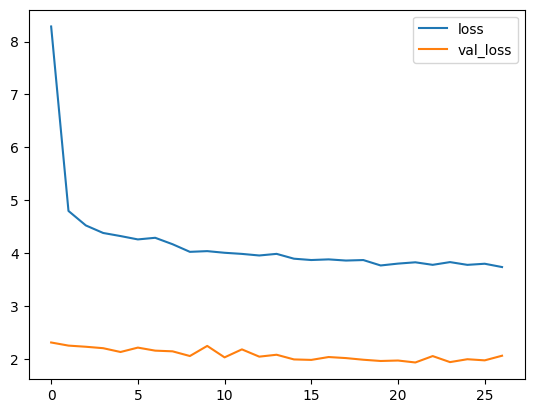

In [ ]:
df_hist = pd.DataFrame(history.history)
df_hist[["loss", "val_loss"]].plot()

predicting test

In [ ]:
y_preds = model.predict(X_test)  # shape: (num_samples, 1)
y_preds = y_preds.flatten()       # optional: make it 1D
mse = mean_squared_error(y_test, y_preds)
mae = mean_absolute_error(y_test, y_preds)

print("MSE:", mse)
print("MAE:", mae)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
MSE: 1.8513068117240379
MAE: 1.0877536545371056


true val/pred val

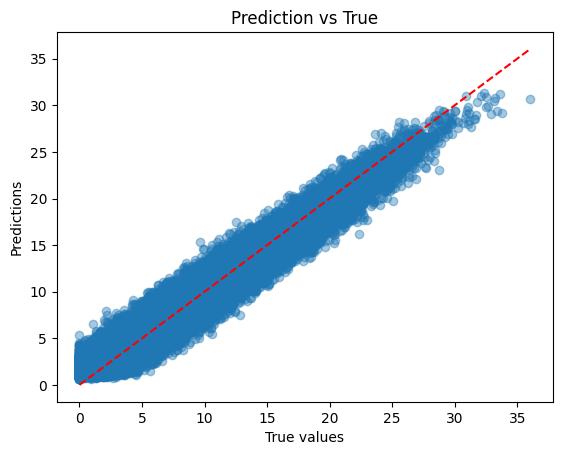

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_preds, alpha=0.4)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("True values")
plt.ylabel("Predictions")
plt.title("Prediction vs True")
plt.show()

determining baseline for loss

In [ ]:
baseline_pred = np.full_like(y_test, y_train.mean())

mse_baseline = mean_squared_error(y_test, baseline_pred)
mae_baseline = mean_absolute_error(y_test, baseline_pred)

print("Baseline MSE:", mse_baseline)
print("Baseline MAE:", mae_baseline)

Baseline MSE: 33.16067123988942
Baseline MAE: 4.664230165017144
